In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pickle import dump, load
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = ('../data/raw/diabetes.csv')
df = pd.read_csv(url)

print(f"Dataset cargado: {df.shape}")
print(df.head())

Dataset cargado: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# LIMPIAR CEROS
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()

for col in cols_with_zeros:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Datos limpios")

Datos limpios


In [4]:
# SEPARAR X E Y
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# SPLIT TRAIN/TEST

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ELIMINAR OUTLIERS

In [6]:
z_scores = np.abs(stats.zscore(X_train_full))
mask_sin_outliers = (z_scores < 3).all(axis=1)

X_train = X_train_full[mask_sin_outliers].copy()
y_train = y_train_full[mask_sin_outliers].copy()

print(f"Datos finales:")
print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")
print(f"Outliers eliminados: {len(X_train_full) - len(X_train)}")

Datos finales:
Train: 574 registros
Test: 154 registros
Outliers eliminados: 40


# XGBOOST BASELINE

In [7]:
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)

y_pred_baseline = xgb_baseline.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print("XGBOOST BASELINE")
print(f"n_estimators: {xgb_baseline.n_estimators}")
print(f"max_depth: {xgb_baseline.max_depth}")
print(f"learning_rate: {xgb_baseline.learning_rate}")
print(f"\nAccuracy: {accuracy_baseline:.4f}")

XGBOOST BASELINE
n_estimators: None
max_depth: None
learning_rate: None

Accuracy: 0.7597


In [8]:
# IMPACTO DE N_ESTIMATORS
n_estimators_values = [10, 50, 100, 200, 300, 500]
results_n_estimators = []

for n in n_estimators_values:
    xgb = XGBClassifier(n_estimators=n, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_n_estimators.append({'n_estimators': n, 'accuracy': acc})
    print(f"n_estimators={n:3d} : Accuracy: {acc:.4f}")

df_n_estimators = pd.DataFrame(results_n_estimators)

n_estimators= 10 : Accuracy: 0.6948
n_estimators= 50 : Accuracy: 0.7792
n_estimators=100 : Accuracy: 0.7597
n_estimators=200 : Accuracy: 0.7532
n_estimators=300 : Accuracy: 0.7468
n_estimators=500 : Accuracy: 0.7468


# GRAFICO N_ESTIMATORS

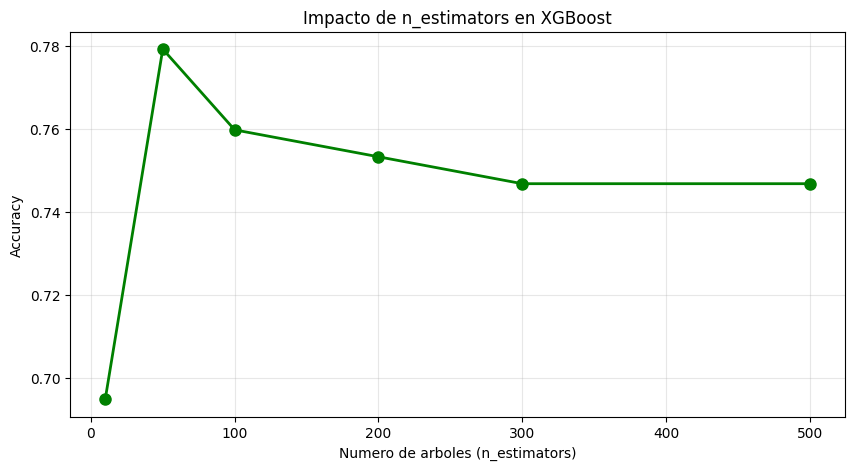


Mejor accuracy: 0.7792 con n_estimators=50


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df_n_estimators['n_estimators'], 
         df_n_estimators['accuracy'], 
         marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Numero de arboles (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Impacto de n_estimators en XGBoost')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMejor accuracy: {df_n_estimators['accuracy'].max():.4f} con n_estimators={df_n_estimators.loc[df_n_estimators['accuracy'].idxmax(), 'n_estimators']}")

# IMPACTO DE LEARNING_RATE

In [10]:
learning_rate_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
results_lr = []

for lr in learning_rate_values:
    xgb = XGBClassifier(n_estimators=100, learning_rate=lr, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_lr.append({'learning_rate': lr, 'accuracy': acc})
    print(f"learning_rate={lr:.2f} -> Accuracy: {acc:.4f}")

df_lr = pd.DataFrame(results_lr)

learning_rate=0.01 -> Accuracy: 0.7403
learning_rate=0.05 -> Accuracy: 0.7403
learning_rate=0.10 -> Accuracy: 0.7662
learning_rate=0.20 -> Accuracy: 0.7532
learning_rate=0.30 -> Accuracy: 0.7597
learning_rate=0.50 -> Accuracy: 0.7403


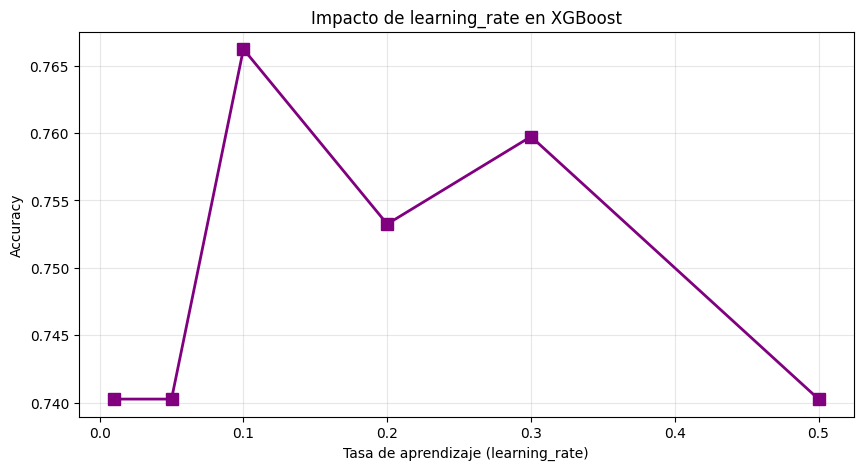


Mejor accuracy: 0.7662 con learning_rate=0.1


In [11]:
# GRAFICO LEARNING_RATE
plt.figure(figsize=(10, 5))
plt.plot(df_lr['learning_rate'], 
         df_lr['accuracy'], 
         marker='s', linewidth=2, markersize=8, color='purple')
plt.xlabel('Tasa de aprendizaje (learning_rate)')
plt.ylabel('Accuracy')
plt.title('Impacto de learning_rate en XGBoost')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMejor accuracy: {df_lr['accuracy'].max():.4f} con learning_rate={df_lr.loc[df_lr['accuracy'].idxmax(), 'learning_rate']}")

# IMPACTO DE MAX_DEPTH

In [12]:
max_depth_values = [3, 4, 5, 6, 7, 8, 10]
results_depth = []

for depth in max_depth_values:
    xgb = XGBClassifier(n_estimators=100, max_depth=depth, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_depth.append({'max_depth': depth, 'accuracy': acc})
    print(f"max_depth={depth:2d} -> Accuracy: {acc:.4f}")

df_depth = pd.DataFrame(results_depth)

max_depth= 3 -> Accuracy: 0.7403
max_depth= 4 -> Accuracy: 0.7727
max_depth= 5 -> Accuracy: 0.7532
max_depth= 6 -> Accuracy: 0.7597
max_depth= 7 -> Accuracy: 0.7338
max_depth= 8 -> Accuracy: 0.7597
max_depth=10 -> Accuracy: 0.7403


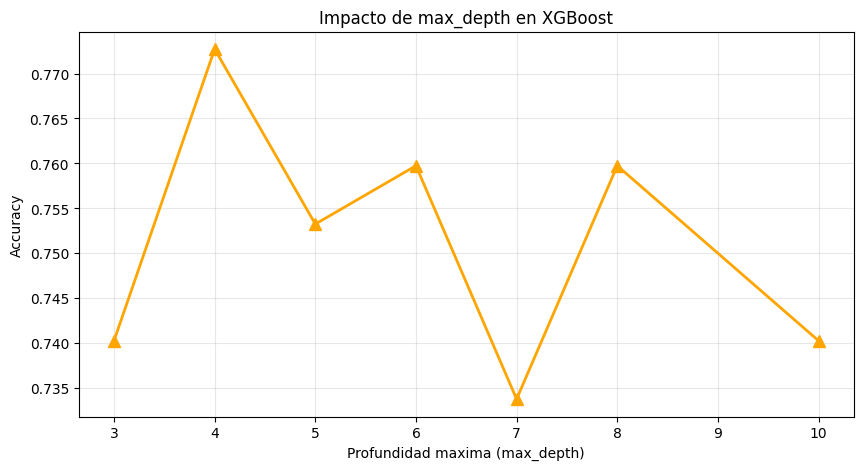


Mejor accuracy: 0.7727 con max_depth=4


In [13]:
# GRAFICO MAX_DEPTH
plt.figure(figsize=(10, 5))
plt.plot(df_depth['max_depth'], 
         df_depth['accuracy'], 
         marker='^', linewidth=2, markersize=8, color='orange')
plt.xlabel('Profundidad maxima (max_depth)')
plt.ylabel('Accuracy')
plt.title('Impacto de max_depth en XGBoost')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMejor accuracy: {df_depth['accuracy'].max():.4f} con max_depth={df_depth.loc[df_depth['accuracy'].idxmax(), 'max_depth']}")

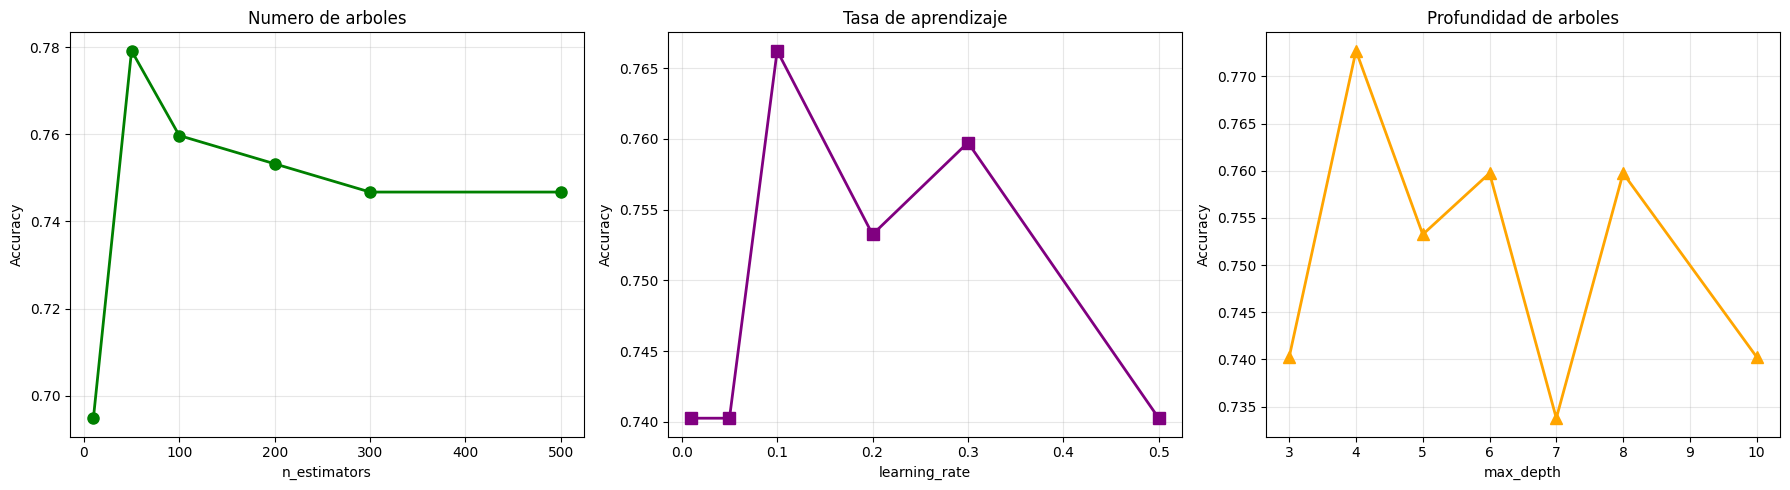

In [14]:
# COMPARACION VISUAL DE HIPERPARAMETROS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# n_estimators
axes[0].plot(df_n_estimators['n_estimators'], df_n_estimators['accuracy'], 
             marker='o', linewidth=2, markersize=8, color='green')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Numero de arboles')
axes[0].grid(True, alpha=0.3)

# learning_rate
axes[1].plot(df_lr['learning_rate'], df_lr['accuracy'], 
             marker='s', linewidth=2, markersize=8, color='purple')
axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Tasa de aprendizaje')
axes[1].grid(True, alpha=0.3)

# max_depth
axes[2].plot(df_depth['max_depth'], df_depth['accuracy'], 
             marker='^', linewidth=2, markersize=8, color='orange')
axes[2].set_xlabel('max_depth')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Profundidad de arboles')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Número de árboles (izquierda):
El accuracy sube rápido hasta 50 árboles, luego se estabiliza. Más de 100 árboles no mejora el resultado.
Tasa de aprendizaje (centro):
Un learning_rate de 0.1 es óptimo. Valores muy bajos (0.01) o muy altos (0.5) empeoran el modelo.
Profundidad de árboles (derecha):
La profundidad óptima es 4. Árboles muy simples (3) o muy complejos (10) funcionan peor.

# GRID SEARCH

In [15]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [5, 6, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

total_combinaciones = 3 * 3 * 3 * 3 * 3
print(f"Total de combinaciones a probar: {total_combinaciones}")

Total de combinaciones a probar: 243


In [16]:
grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nRESULTADOS DE LA OPTIMIZACION")
print(f"\nMejores parametros:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor accuracy en validacion cruzada: {grid.best_score_:.4f}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits



RESULTADOS DE LA OPTIMIZACION

Mejores parametros:
  colsample_bytree: 1.0
  learning_rate: 0.1
  max_depth: 5
  n_estimators: 100
  subsample: 0.8

Mejor accuracy en validacion cruzada: 0.7683


# EVALUACION EN TEST

In [17]:
best_xgb = grid.best_estimator_

y_pred_test = best_xgb.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("EVALUACION EN CONJUNTO DE PRUEBA")
print(f"\nAccuracy en test: {accuracy_test:.4f}")
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['No Diabetes', 'Diabetes']))

EVALUACION EN CONJUNTO DE PRUEBA

Accuracy en test: 0.7403

Reporte de clasificacion:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.81      0.80       100
    Diabetes       0.63      0.61      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



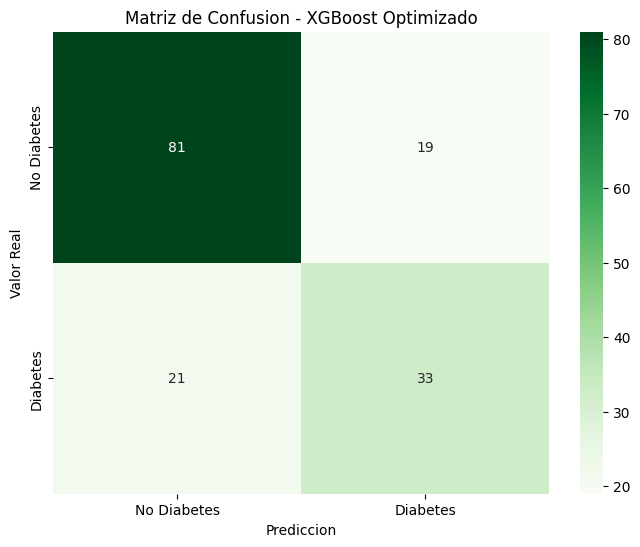


Diabetes NO detectada (Falsos Negativos): 21 casos
Falsas alarmas (Falsos Positivos): 19 casos


In [18]:
#MATRIZ DE CONFUSION
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Valor Real')
plt.xlabel('Prediccion')
plt.title('Matriz de Confusion - XGBoost Optimizado')
plt.show()

print(f"\nDiabetes NO detectada (Falsos Negativos): {cm[1,0]} casos")
print(f"Falsas alarmas (Falsos Positivos): {cm[0,1]} casos")

El modelo acierta 81+33 = 114 casos de 154 totales (74%).

Importancia de caracteristicas:
             Caracteristica  Importancia
1                   Glucose     0.269701
5                       BMI     0.131375
7                       Age     0.119512
4                   Insulin     0.108496
6  DiabetesPedigreeFunction     0.105338
0               Pregnancies     0.098971
2             BloodPressure     0.086285
3             SkinThickness     0.080322


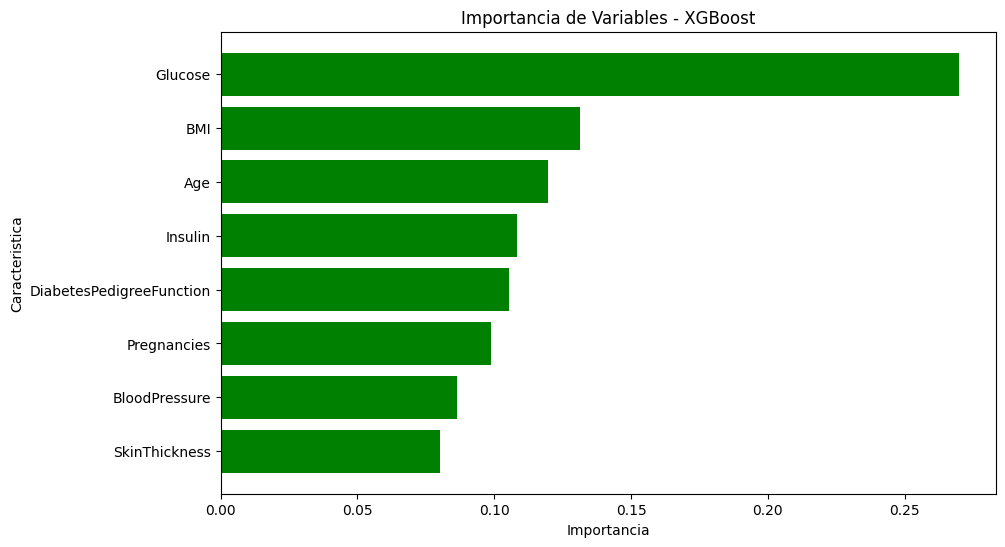

In [19]:
# IMPORTANCIA DE CARACTERISTICAS
importancias = pd.DataFrame({
    'Caracteristica': X.columns,
    'Importancia': best_xgb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Importancia de caracteristicas:")
print(importancias)

plt.figure(figsize=(10, 6))
plt.barh(importancias['Caracteristica'], importancias['Importancia'], color='green')
plt.xlabel('Importancia')
plt.ylabel('Caracteristica')
plt.title('Importancia de Variables - XGBoost')
plt.gca().invert_yaxis()
plt.show()

Glucose es la variable MÁS importante para predecir diabetes (casi 30% de importancia), seguida de BMI y Age. SkinThickness es la menos importante.

In [20]:
# GUARDAR MODELO
nombre_modelo = "xgboost_diabetes_optimizado_42.sav"
dump(best_xgb, open(nombre_modelo, "wb"))
print(f"Modelo guardado: {nombre_modelo}")

parametros = {
    'modelo': 'XGBoost',
    'best_params': grid.best_params_,
    'cv_score': float(grid.best_score_),
    'test_accuracy': float(accuracy_test),
    'random_state': 42,
    'train_size': len(X_train),
    'test_size': len(X_test)
}

with open('xgboost_parametros_42.json', 'w') as f:
    json.dump(parametros, f, indent=4)

Modelo guardado: xgboost_diabetes_optimizado_42.sav


#  CARGAR MODELOS ANTERIORES

In [22]:
dt_model = load(open('decision_tree_diabetes_CON_outliers_optimizado_42.sav', 'rb'))
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

rf_model = load(open('random_forest_diabetes_optimizado_42.sav', 'rb'))
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_xgb = accuracy_test

print("COMPARACION DE ACCURACY")
print(f"Decision Tree: {accuracy_dt:.4f}")
print(f"Random Forest: {accuracy_rf:.4f}")
print(f"XGBoost:       {accuracy_xgb:.4f}")

COMPARACION DE ACCURACY
Decision Tree: 0.6883
Random Forest: 0.7403
XGBoost:       0.7403


# MATRICES DE CONFUSION COMPARATIVAS

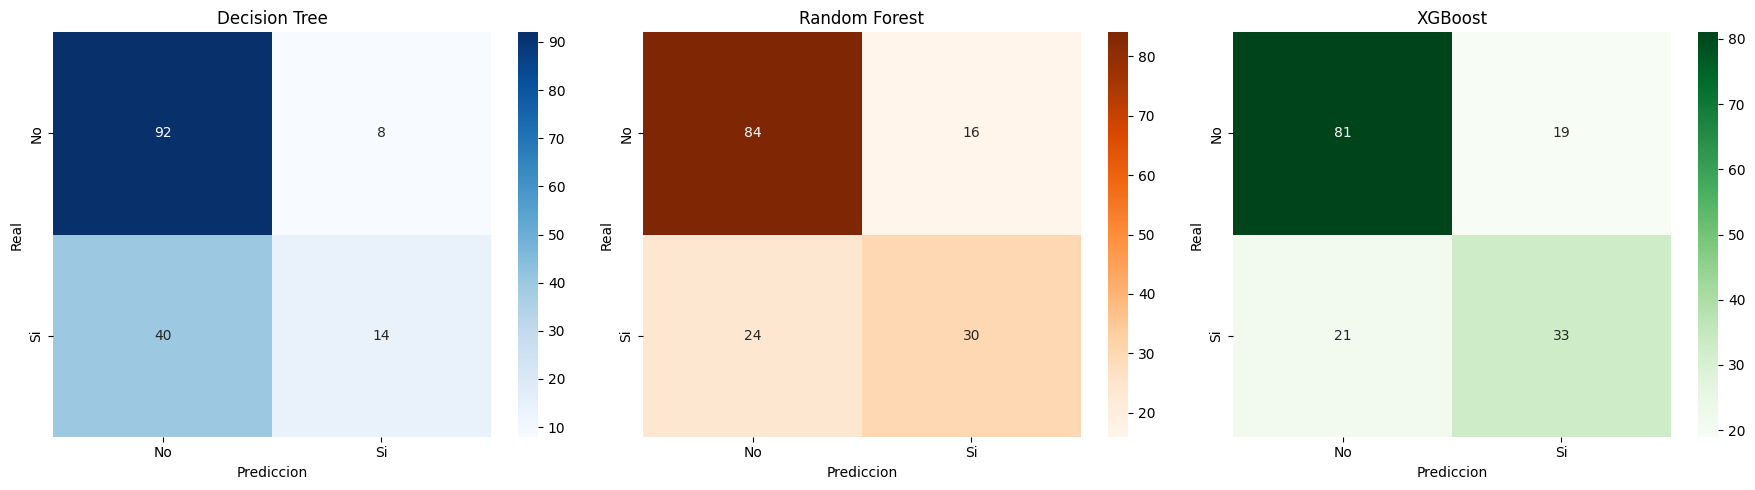

In [24]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Si'], yticklabels=['No', 'Si'])
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Prediccion')
axes[0].set_title('Decision Tree')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No', 'Si'], yticklabels=['No', 'Si'])
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Prediccion')
axes[1].set_title('Random Forest')

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['No', 'Si'], yticklabels=['No', 'Si'])
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Prediccion')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()

Decision Tree (azul): 40 Falsos Negativos - el PEOR
Random Forest (naranja): 24 Falsos Negativos - mejora mucho
XGBoost (verde): 21 Falsos Negativos - el MEJOR
Los tres tienen accuracy similar (~74%), pero XGBoost comete menos errores críticos.

# ANALISIS DE FALSOS NEGATIVOS

ERRORES CRITICOS (Diabetes NO detectada - Falsos Negativos)
Decision Tree: 40 casos
Random Forest: 24 casos
XGBoost:       21 casos


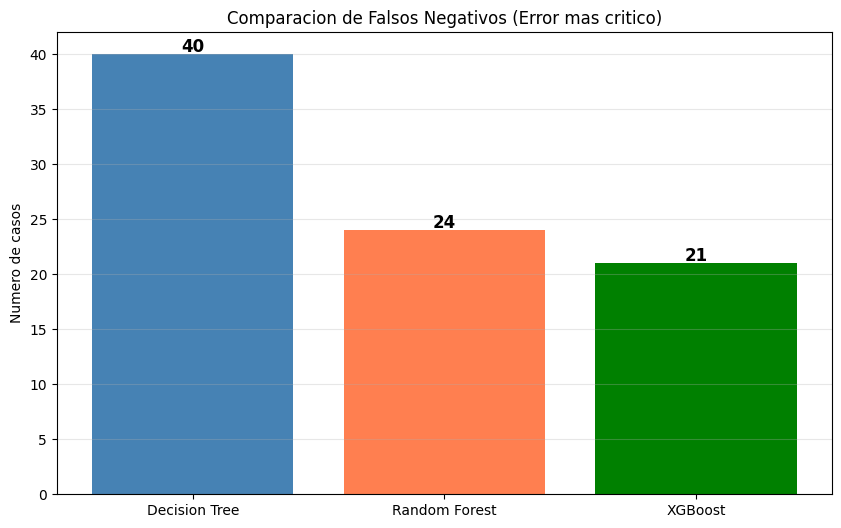


XGBoost reduce los falsos negativos en 19 casos comparado con Decision Tree


In [25]:
fn_dt = cm_dt[1, 0]
fn_rf = cm_rf[1, 0]
fn_xgb = cm_xgb[1, 0]

print("ERRORES CRITICOS (Diabetes NO detectada - Falsos Negativos)")
print(f"Decision Tree: {fn_dt} casos")
print(f"Random Forest: {fn_rf} casos")
print(f"XGBoost:       {fn_xgb} casos")

plt.figure(figsize=(10, 6))
bars = plt.bar(['Decision Tree', 'Random Forest', 'XGBoost'], 
               [fn_dt, fn_rf, fn_xgb],
               color=['steelblue', 'coral', 'green'])
plt.ylabel('Numero de casos')
plt.title('Comparacion de Falsos Negativos (Error mas critico)')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, [fn_dt, fn_rf, fn_xgb]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             str(val), ha='center', fontweight='bold', fontsize=12)

plt.show()

print(f"\nXGBoost reduce los falsos negativos en {fn_dt - fn_xgb} casos comparado con Decision Tree")

XGBoost reduce los falsos negativos casi a la mitad comparado con Decision Tree (de 40 a 21 casos). Esto es crítico en medicina porque significa menos pacientes con diabetes sin detectar.

# RESUMEN FINAL

In [35]:
print(" RESUMEN COMPARATIVO DE LOS TRES MODELOS")

print(f"""

ERRORES CRITICOS (Diabetes no detectada):
  Decision Tree:  {fn_dt} casos
  Random Forest:  {fn_rf} casos
  XGBoost:        {fn_xgb} casos  < MEJOR


DECISION: XGBoost

JUSTIFICACION:
  - Mejor accuracy general ({accuracy_xgb:.4f})
  - Menos falsos negativos ({fn_xgb} casos), critico en medicina
  - XGBoost es el mejor modelo porque comete menos errores críticos, aunque tenga el mismo accuracy que Random Forest.
""")


 RESUMEN COMPARATIVO DE LOS TRES MODELOS


ERRORES CRITICOS (Diabetes no detectada):
  Decision Tree:  40 casos
  Random Forest:  24 casos
  XGBoost:        21 casos  < MEJOR


DECISION: XGBoost

JUSTIFICACION:
  - Mejor accuracy general (0.7403)
  - Menos falsos negativos (21 casos), critico en medicina
  - XGBoost es el mejor modelo porque comete menos errores críticos, aunque tenga el mismo accuracy que Random Forest.

